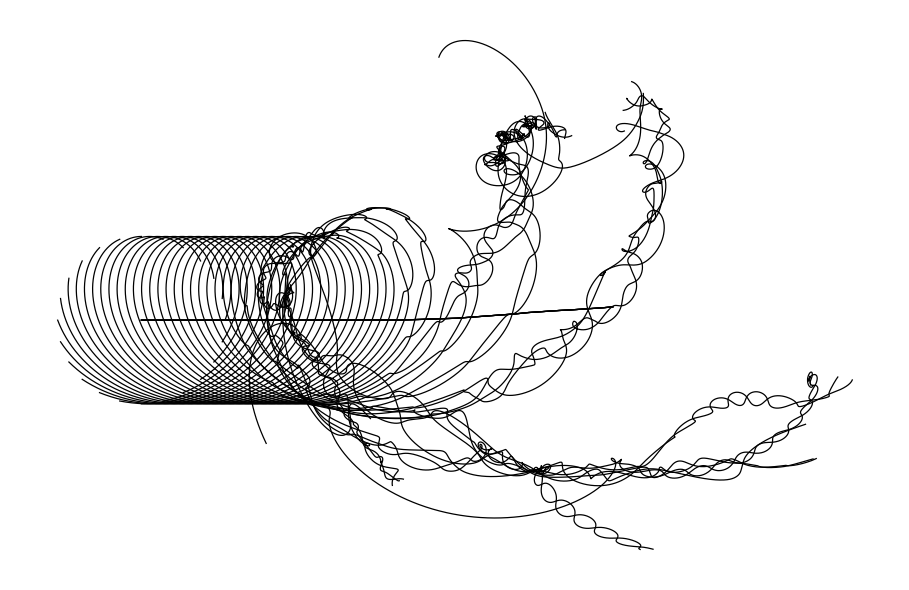

In [70]:
# N-body polygon drift art with escape detection, removal, and acceleration clamping
import numpy as np
import matplotlib.pyplot as plt

# ---------- parameters ----------
SEED = 7
np.random.seed(SEED)

G = 1.0
N_BODIES = 24           # 3 for triangle, any N >= 3
M_BASE = 1.0
MASS_PERTURB_INDEX = 0
MASS_PERTURB_FACTOR = 1.00

R = 7.0                 # initial circle radius
dt = 0.02
steps = 4_000

# force regularization
soft_eps = 5e-3         # Plummer softening (base)
R_MIN = 0.04            # never let pair distance fall below this (smoothly)
A_PAIR_MAX = 2.0        # max accel contribution from any single pair
A_MAX = 3.0             # max total accel magnitude per body

drift_speed = 0.5
linewidth = 0.9
fade_tail = False
figsize = (14, 6)
bg = "white"

# small jitters to seed breakup
pos_radius_jitter = 0.0
vel_scale_jitter = 0.0

# escape detection
ESCAPE_Z = 1000.0
ESCAPE_PERSIST = 300
MIN_RADIAL_SPEED = 0.02

# ---------- helpers ----------
def clamp_vecs(v, max_norm):
    """Scale rows of v so that ||row|| <= max_norm (continuous)."""
    n = np.linalg.norm(v, axis=1) + 1e-12
    s = np.minimum(1.0, max_norm / n)
    return v * s[:, None]

def pairwise_acc_masked(p, m, active, G=1.0, eps=1e-3,
                        r_min=0.0, a_pair_max=None, a_total_max=None):
    """Acceleration only among active bodies with smooth clamping."""
    idx = np.where(active)[0]
    a_full = np.zeros_like(p)
    if len(idx) <= 1:
        return a_full

    P = p[idx]
    M = m[idx]
    A = np.zeros_like(P)

    rmin2 = r_min * r_min
    eps2 = eps * eps

    for ii in range(len(idx)):
        d = P - P[ii]                                   # (K,2)
        dist2 = np.sum(d * d, axis=1)
        dist2 = np.maximum(dist2, rmin2)
        dist2 = dist2 + eps2

        mask = np.ones(len(idx), dtype=bool); mask[ii] = False
        d_ij = d[mask]
        m_ij = M[mask]
        invr3 = dist2[mask] ** (-1.5)

        contrib = (G * m_ij)[:, None] * d_ij * invr3[:, None]

        if a_pair_max is not None:
            contrib = clamp_vecs(contrib, a_pair_max)

        acc_i = contrib.sum(axis=0)
        A[ii] = acc_i

    if a_total_max is not None:
        n = np.linalg.norm(A, axis=1) + 1e-12
        s = np.minimum(1.0, a_total_max / n)
        A = A * s[:, None]

    a_full[idx] = A
    return a_full

def initial_polygon_rotation_velocity(p, m_equal, G=1.0):
    """Tangential speeds so average centripetal matches radial gravity at t=0."""
    c = p.mean(axis=0)
    rel = p - c
    Rvals = np.linalg.norm(rel, axis=1)
    R0 = np.mean(Rvals)
    acc = pairwise_acc_masked(p, m_equal, np.ones(len(p), bool), G, eps=soft_eps,
                              r_min=R_MIN*0.0, a_pair_max=None, a_total_max=None)
    a_rad = []
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        a_rad.append(-np.dot(acc[i], rhat))
    a_rad = max(np.mean(a_rad), 0.0)
    omega = np.sqrt(a_rad / (R0 + 1e-12))
    v = np.zeros_like(p)
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        that = np.array([-rhat[1], rhat[0]])
        v[i] = omega * R0 * that
    return v

# ---------- initial state ----------
angles = np.linspace(0.0, 2*np.pi, N_BODIES, endpoint=False)
pos = np.stack([R*np.cos(angles), R*np.sin(angles)], axis=1)

masses = np.full(N_BODIES, M_BASE, float)
masses[MASS_PERTURB_INDEX] *= MASS_PERTURB_FACTOR

m_equal = np.full(N_BODIES, M_BASE, float)
vel = initial_polygon_rotation_velocity(pos, m_equal, G)

# gentle jitters
pos *= (1.0 + pos_radius_jitter * np.sin(angles))[:, None]
vel *= (1.0 + np.linspace(-vel_scale_jitter, vel_scale_jitter, N_BODIES))[:, None]

# state
p = pos.copy()
v = vel.copy()
active = np.ones(N_BODIES, dtype=bool)
escape_counter = np.zeros(N_BODIES, dtype=int)
ended_at = np.full(N_BODIES, steps, dtype=int)

# store trajectories, NaN after removal to break the line
traj = np.full((steps, N_BODIES, 2), np.nan, float)
# center of mass trajectory (of active bodies), with drift applied
com_traj = np.full((steps, 2), np.nan, float)

# ---------- integrate with escape removal ----------
for t in range(steps):
    drift = np.array([drift_speed * t * dt, 0.0])
    traj[t, active] = p[active] + drift

    # compute clamped acceleration
    a0 = pairwise_acc_masked(
        p, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    p_half = p.copy()
    v_new = v.copy()
    p_half[active] = p[active] + v[active]*dt + 0.5*a0[active]*(dt*dt)

    a1 = pairwise_acc_masked(
        p_half, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    v_new[active] = v[active] + 0.5*(a0[active] + a1[active])*dt

    # propose next state
    p_next = p_half
    v_next = v_new

    # center of mass of currently active bodies
    idx = np.where(active)[0]
    if len(idx) >= 1:
        m_act = masses[idx]
        com = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
        com_traj[t] = com + drift

    # escape detection
    if len(idx) >= 2:
        m_act = masses[idx]
        com_tmp = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
        rel = p_next - com_tmp
        r = np.linalg.norm(rel, axis=1)

        r_act = r[active]
        r_med = np.median(r_act)
        mad = np.median(np.abs(r_act - r_med)) + 1e-9

        rhat = np.zeros_like(rel)
        rhat[active] = rel[active] / (np.linalg.norm(rel[active], axis=1)[:, None] + 1e-12)
        v_rad = np.sum(v_next * rhat, axis=1)

        candidates = (r > r_med + ESCAPE_Z*mad) & (v_rad > MIN_RADIAL_SPEED) & active
        escape_counter[candidates] += 1
        escape_counter[~candidates & active] = 0

        to_remove = (escape_counter >= ESCAPE_PERSIST) & active
        if np.any(to_remove):
            ended_at[to_remove] = t + 1
            active[to_remove] = False

    p = p_next
    v = v_next

    if active.sum() <= 1:
        break

# ---------- plot ----------
plt.figure(figsize=figsize, facecolor=bg)
ax = plt.gca(); ax.set_facecolor(bg)

# subsample for plotting
T = traj[::2]
COM = com_traj[::2]

# plot planets in black
if fade_tail:
    alphas = np.linspace(0.05, 0.95, T.shape[0])
    for k in range(N_BODIES):
        t_end = min(ended_at[k] // 2, T.shape[0])
        if t_end <= 1:
            continue
        for i in range(t_end-1):
            if np.any(np.isnan(T[i:i+2, k, :])):
                continue
            x = T[i:i+2, k, 0]; y = T[i:i+2, k, 1]
            ax.plot(x, y, color="k", lw=linewidth, alpha=alphas[i])
else:
    for k in range(N_BODIES):
        t_end = min(ended_at[k] // 2, T.shape[0])
        if t_end <= 2:
            continue
        xy = T[:t_end, k, :]
        mask = ~np.isnan(xy[:, 0])
        ax.plot(xy[mask, 0], xy[mask, 1], color="k", lw=linewidth)

# bounds for jitter scaling
xmin = np.nanmin(T[:, :, 0]); xmax = np.nanmax(T[:, :, 0])
ymin = np.nanmin(T[:, :, 1]); ymax = np.nanmax(T[:, :, 1])
xspan = (xmax - xmin + 1e-9)
yspan = (ymax - ymin + 1e-9)
span = max(xspan, yspan)

# plot COM trajectory in black, 5 passes with tiny jitter for pen thickness
mask_com = ~np.isnan(COM[:, 0])
rng = np.random.default_rng(SEED + 12345)
jitter_std = 0.000 * span  # small spatial jitter for thicker pen stroke

for _ in range(5):
    jitter = rng.normal(scale=jitter_std, size=COM.shape)
    ax.plot(COM[mask_com, 0] + jitter[mask_com, 0],
            COM[mask_com, 1] + jitter[mask_com, 1],
            color="k", lw=linewidth)

ax.set_aspect("equal", adjustable="box")
ax.axis("off")

xpad = 0.06 * xspan
ypad = 0.06 * yspan
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

plt.tight_layout()
plt.savefig("03_n_polygon_breakup_2.svg", bbox_inches="tight")
plt.show()


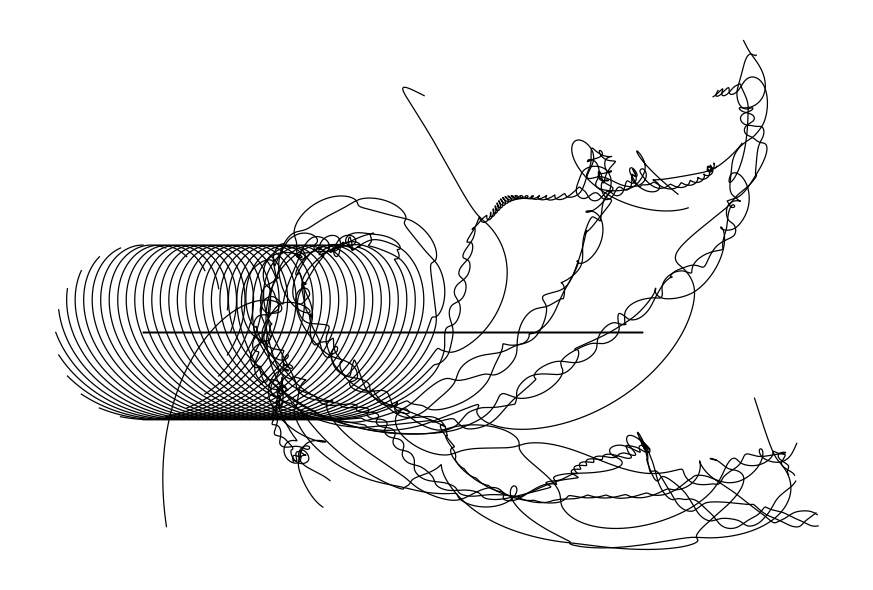

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- parameters ----------
SEED = 7
np.random.seed(SEED)

G = 1.0
N_BODIES = 24
M_BASE = 1.0
MASS_PERTURB_INDEX = 0
MASS_PERTURB_FACTOR = 1.00

R = 7.0
dt = 0.04
steps = 2_000

# force regularization
soft_eps = 5e-3
R_MIN = 0.5
A_PAIR_MAX = 1e10#2.0
A_MAX = 1e10#3.0

drift_speed = 0.5
linewidth = 0.9
fade_tail = False
figsize = (14, 6)
bg = "white"

# small jitters to seed breakup
pos_radius_jitter = 0.0
vel_scale_jitter = 0.0

# escape detection
ESCAPE_Z = 1000.0
ESCAPE_PERSIST = 300
MIN_RADIAL_SPEED = 0.02

# ---------- symmetry schedule ----------
# modes: "none", "all", "evenodd", "nth:k"
SYMMETRY_SCHEDULE = [
    #(0, "all"),
    #(800, "evenodd"),
    #(1600, "nth:3"),
]

# ---------- helpers ----------
def clamp_vecs(v, max_norm):
    n = np.linalg.norm(v, axis=1) + 1e-12
    s = np.minimum(1.0, max_norm / n)
    return v * s[:, None]

def pairwise_acc_masked(p, m, active, G=1.0, eps=1e-3,
                        r_min=0.0, a_pair_max=None, a_total_max=None):
    idx = np.where(active)[0]
    a_full = np.zeros_like(p)
    if len(idx) <= 1:
        return a_full

    P = p[idx]
    M = m[idx]
    A = np.zeros_like(P)

    rmin2 = r_min * r_min
    eps2 = eps * eps

    for ii in range(len(idx)):
        d = P - P[ii]
        dist2 = np.sum(d * d, axis=1)
        dist2 = np.maximum(dist2, rmin2) + eps2

        mask = np.ones(len(idx), dtype=bool); mask[ii] = False
        d_ij = d[mask]
        m_ij = M[mask]
        invr3 = dist2[mask] ** (-1.5)

        contrib = (G * m_ij)[:, None] * d_ij * invr3[:, None]
        if a_pair_max is not None:
            contrib = clamp_vecs(contrib, a_pair_max)
        A[ii] = contrib.sum(axis=0)

    if a_total_max is not None:
        n = np.linalg.norm(A, axis=1) + 1e-12
        s = np.minimum(1.0, a_total_max / n)
        A = A * s[:, None]

    a_full[idx] = A
    return a_full

def initial_polygon_rotation_velocity(p, m_equal, G=1.0):
    c = p.mean(axis=0)
    rel = p - c
    Rvals = np.linalg.norm(rel, axis=1)
    R0 = np.mean(Rvals)
    acc = pairwise_acc_masked(p, m_equal, np.ones(len(p), bool), G, eps=soft_eps,
                              r_min=0.0, a_pair_max=None, a_total_max=None)
    a_rad = []
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        a_rad.append(-np.dot(acc[i], rhat))
    a_rad = max(np.mean(a_rad), 0.0)
    omega = np.sqrt(a_rad / (R0 + 1e-12))
    v = np.zeros_like(p)
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        that = np.array([-rhat[1], rhat[0]])
        v[i] = omega * R0 * that
    return v

def current_mode(t, schedule):
    mode = "none"
    for ts, m in schedule:
        if t >= ts:
            mode = m
        else:
            break
    return mode

def parse_groups(mode, indices):
    if mode == "none":
        return []
    if mode == "all":
        return [indices.copy()] if len(indices) >= 2 else []
    if mode == "evenodd":
        ev = indices[indices % 2 == 0]
        od = indices[indices % 2 == 1]
        groups = []
        if len(ev) >= 2: groups.append(ev)
        if len(od) >= 2: groups.append(od)
        return groups
    if mode.startswith("nth:"):
        try:
            k = int(mode.split(":")[1])
        except:
            return []
        if k < 2:
            return []
        groups = []
        for start in range(k):
            g = indices[start::k]
            if len(g) >= 2:
                groups.append(g)
        return groups
    return []

def angle_mean(a):
    return np.arctan2(np.mean(np.sin(a)), np.mean(np.cos(a)))

def symmetrize_group_inplace(p, v, m, group_idx):
    """Symmetrise positions and velocities of a group in place."""
    if len(group_idx) < 2:
        return

    mg = m[group_idx]
    Pg = p[group_idx]
    Vg = v[group_idx]

    # weighted COM
    COM = (mg[:, None] * Pg).sum(axis=0) / (mg.sum() + 1e-12)

    # complex forms
    rel = Pg - COM
    z = rel[:, 0] + 1j * rel[:, 1]
    vc = Vg[:, 0] + 1j * Vg[:, 1]

    # order by current polar angle
    theta = np.angle(z)
    order = np.argsort(theta)
    z = z[order]
    vc = vc[order]
    ids_sorted = group_idx[order]

    K = len(z)
    phis = 2.0 * np.pi * np.arange(K) / K

    # estimate alpha from position phases against ideal phis
    theta_sorted = np.angle(z)
    delta = theta_sorted - phis
    delta = (delta + np.pi) % (2.0 * np.pi) - np.pi
    alpha = angle_mean(delta)

    # align both position and velocity by removing alpha
    z_aligned = z * np.exp(-1j * alpha)
    vc_aligned = vc * np.exp(-1j * alpha)

    # position template: mean vector gives radius and beta
    mean_vec = np.mean(z_aligned)
    r = np.abs(mean_vec)
    beta = np.angle(mean_vec)

    # perfect n-gon positions in aligned frame
    z_template = r * np.exp(1j * (phis + beta))

    # velocity template:
    # bring each velocity to index 0 frame by removing its local phase (phis+beta),
    # average to get v0, then replicate with the same phases
    vc0 = vc_aligned * np.exp(-1j * (phis + beta))
    v0 = np.mean(vc0)
    vc_template = v0 * np.exp(1j * (phis + beta))

    # rotate back by +alpha and map to xy
    z_new = z_template * np.exp(1j * alpha)
    vc_new = vc_template * np.exp(1j * alpha)

    P_new_sorted = COM[None, :] + np.column_stack([np.real(z_new), np.imag(z_new)])
    V_new_sorted = np.column_stack([np.real(vc_new), np.imag(vc_new)])

    p[ids_sorted] = P_new_sorted
    v[ids_sorted] = V_new_sorted

# ---------- initial state ----------
angles = np.linspace(0.0, 2*np.pi, N_BODIES, endpoint=False)
pos = np.stack([R*np.cos(angles), R*np.sin(angles)], axis=1)

masses = np.full(N_BODIES, M_BASE, float)
masses[MASS_PERTURB_INDEX] *= MASS_PERTURB_FACTOR

m_equal = np.full(N_BODIES, M_BASE, float)
vel = initial_polygon_rotation_velocity(pos, m_equal, G)

# gentle jitters
pos *= (1.0 + pos_radius_jitter * np.sin(angles))[:, None]
vel *= (1.0 + np.linspace(-vel_scale_jitter, vel_scale_jitter, N_BODIES))[:, None]

# state
p = pos.copy()
v = vel.copy()
active = np.ones(N_BODIES, dtype=bool)
escape_counter = np.zeros(N_BODIES, dtype=int)
ended_at = np.full(N_BODIES, steps, dtype=int)

# store trajectories, NaN after removal
traj = np.full((steps, N_BODIES, 2), np.nan, float)
com_traj = np.full((steps, 2), np.nan, float)

# ---------- integrate with scheduled symmetry ----------
for t in range(steps):
    drift = np.array([drift_speed * t * dt, 0.0])
    traj[t, active] = p[active] + drift

    a0 = pairwise_acc_masked(
        p, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    p_half = p.copy()
    v_new = v.copy()
    p_half[active] = p[active] + v[active]*dt + 0.5*a0[active]*(dt*dt)

    a1 = pairwise_acc_masked(
        p_half, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    v_new[active] = v[active] + 0.5*(a0[active] + a1[active])*dt

    # proposed next state
    p_next = p_half
    v_next = v_new

    # scheduled symmetry on positions and velocities
    mode = current_mode(t, SYMMETRY_SCHEDULE)
    if mode != "none":
        idx_act = np.where(active)[0]
        for g in parse_groups(mode, idx_act):
            symmetrize_group_inplace(p_next, v_next, masses, g)

    # COM of active bodies
    idx = np.where(active)[0]
    if len(idx) >= 1:
        m_act = masses[idx]
        com = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
        com_traj[t] = com + drift

    # escape detection
    if len(idx) >= 2:
        m_act = masses[idx]
        com_tmp = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
        rel = p_next - com_tmp
        r = np.linalg.norm(rel, axis=1)

        r_act = r[active]
        r_med = np.median(r_act)
        mad = np.median(np.abs(r_act - r_med)) + 1e-9

        rhat = np.zeros_like(rel)
        rhat[active] = rel[active] / (np.linalg.norm(rel[active], axis=1)[:, None] + 1e-12)
        v_rad = np.sum(v_next * rhat, axis=1)

        candidates = (r > r_med + ESCAPE_Z*mad) & (v_rad > MIN_RADIAL_SPEED) & active
        escape_counter[candidates] += 1
        escape_counter[~candidates & active] = 0

        to_remove = (escape_counter >= ESCAPE_PERSIST) & active
        if np.any(to_remove):
            ended_at[to_remove] = t + 1
            active[to_remove] = False

    p = p_next
    v = v_next

    if active.sum() <= 1:
        break

# ---------- plot ----------
plt.figure(figsize=figsize, facecolor=bg)
ax = plt.gca(); ax.set_facecolor(bg)

T = traj[::2]
COM = com_traj[::2]

if fade_tail:
    alphas = np.linspace(0.05, 0.95, T.shape[0])
    for k in range(N_BODIES):
        t_end = min(ended_at[k] // 2, T.shape[0])
        if t_end <= 1:
            continue
        for i in range(t_end - 1):
            if np.any(np.isnan(T[i:i+2, k, :])): continue
            x = T[i:i+2, k, 0]; y = T[i:i+2, k, 1]
            ax.plot(x, y, color="k", lw=linewidth, alpha=alphas[i])
else:
    for k in range(N_BODIES):
        t_end = min(ended_at[k] // 2, T.shape[0])
        if t_end <= 2: continue
        xy = T[:t_end, k, :]
        mask = ~np.isnan(xy[:, 0])
        ax.plot(xy[mask, 0], xy[mask, 1], color="k", lw=linewidth)

mask_com = ~np.isnan(COM[:, 0])
rng = np.random.default_rng(SEED + 12345)
for _ in range(5):
    jitter = rng.normal(scale=0.0, size=COM.shape)
    ax.plot(COM[mask_com, 0] + jitter[mask_com, 0],
            COM[mask_com, 1] + jitter[mask_com, 1],
            color="k", lw=linewidth)

ax.set_aspect("equal", adjustable="box")
ax.axis("off")

xmin = np.nanmin(T[:, :, 0]); xmax = np.nanmax(T[:, :, 0])
ymin = np.nanmin(T[:, :, 1]); ymax = np.nanmax(T[:, :, 1])
xspan = (xmax - xmin + 1e-9); yspan = (ymax - ymin + 1e-9)
xpad = 0.06 * xspan; ypad = 0.06 * yspan
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

plt.tight_layout()
plt.savefig("03_n_polygon_breakup_scheduled_vel.svg", bbox_inches="tight")
plt.show()


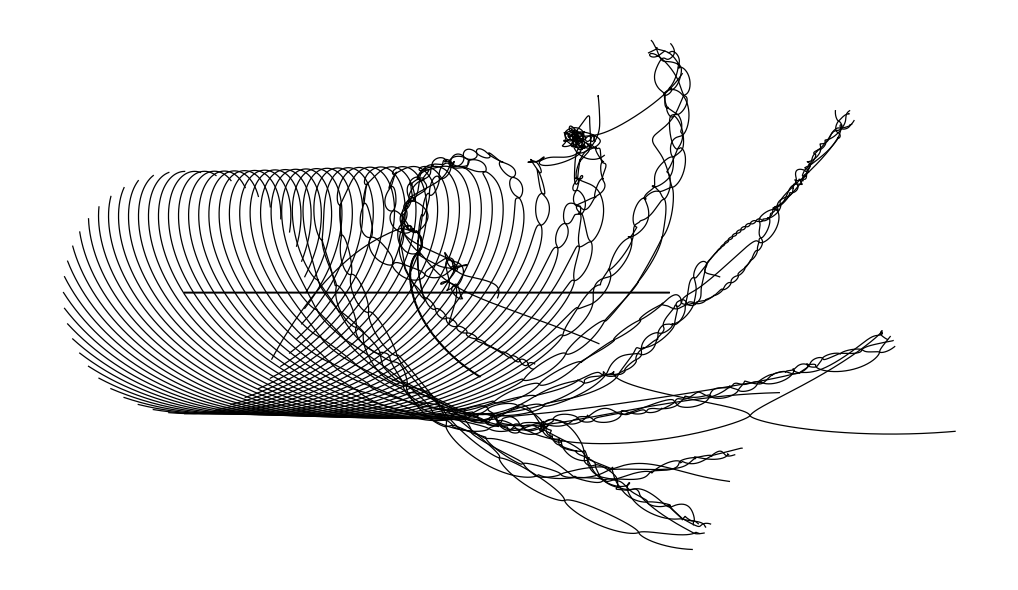

In [141]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- parameters ----------
SEED = 7
np.random.seed(SEED)

G = 1.0
N_BODIES = 48
M_BASE = 1.0
MASS_PERTURB_INDEX = 0
MASS_PERTURB_FACTOR = 1.00

R = 50.0
dt = 0.04
steps = 10_000

# force regularization
soft_eps = 5e-3
R_MIN = 0.5
A_PAIR_MAX = 1e10
A_MAX = 1e10

# plotting
drift_speed = 0.5
linewidth = 0.9
fade_tail = False
figsize = (14, 6)
bg = "white"

# jitters
pos_radius_jitter = 0.0
vel_scale_jitter = 0.0

# start speed controls
V_FACTOR = 1.01       # 1.0 circular, <1 inward drift, >1 outward
V_RADIAL = 0.0#-0.15      # extra radial fraction of circular speed (negative = inward)
V_NOISE = 0.0#0.02        # random velocity noise fraction of circular speed

# escape detection toggle
ESCAPE_ON = False
ESCAPE_Z = 1000.0
ESCAPE_PERSIST = 300
MIN_RADIAL_SPEED = 0.02

# ---------- helpers ----------
def clamp_vecs(v, max_norm):
    n = np.linalg.norm(v, axis=1) + 1e-12
    s = np.minimum(1.0, max_norm / n)
    return v * s[:, None]

def pairwise_acc_masked(p, m, active, G=1.0, eps=1e-3,
                        r_min=0.0, a_pair_max=None, a_total_max=None):
    idx = np.where(active)[0]
    a_full = np.zeros_like(p)
    if len(idx) <= 1:
        return a_full

    P = p[idx]
    M = m[idx]
    A = np.zeros_like(P)

    rmin2 = r_min * r_min
    eps2 = eps * eps

    for ii in range(len(idx)):
        d = P - P[ii]
        dist2 = np.sum(d * d, axis=1)
        dist2 = np.maximum(dist2, rmin2) + eps2

        mask = np.ones(len(idx), dtype=bool); mask[ii] = False
        d_ij = d[mask]
        m_ij = M[mask]
        invr3 = dist2[mask] ** (-1.5)

        contrib = (G * m_ij)[:, None] * d_ij * invr3[:, None]
        if a_pair_max is not None:
            contrib = clamp_vecs(contrib, a_pair_max)
        A[ii] = contrib.sum(axis=0)

    if a_total_max is not None:
        n = np.linalg.norm(A, axis=1) + 1e-12
        s = np.minimum(1.0, a_total_max / n)
        A = A * s[:, None]

    a_full[idx] = A
    return a_full

def initial_polygon_rotation_velocity(p, m_equal, G=1.0):
    """Return circular orbit tangential velocity field at t=0."""
    c = p.mean(axis=0)
    rel = p - c
    Rvals = np.linalg.norm(rel, axis=1)
    R0 = np.mean(Rvals)

    acc = pairwise_acc_masked(
        p, m_equal, np.ones(len(p), bool), G,
        eps=soft_eps, r_min=0.0, a_pair_max=None, a_total_max=None
    )
    # average inward acceleration magnitude on the mean ring
    a_rad = []
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        a_rad.append(-np.dot(acc[i], rhat))
    a_rad = max(np.mean(a_rad), 0.0)

    omega = np.sqrt(a_rad / (R0 + 1e-12))
    speed_circ = omega * R0

    # unit tangents
    v = np.zeros_like(p)
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        that = np.array([-rhat[1], rhat[0]])
        v[i] = speed_circ * that
    return v, speed_circ, (rel / (np.linalg.norm(rel, axis=1)[:, None] + 1e-12))

# ---------- initial state ----------
angles = np.linspace(0.0, 2*np.pi, N_BODIES, endpoint=False)
pos = np.stack([R*np.cos(angles), R*np.sin(angles)], axis=1)

masses = np.full(N_BODIES, M_BASE, float)
masses[MASS_PERTURB_INDEX] *= MASS_PERTURB_FACTOR
m_equal = np.full(N_BODIES, M_BASE, float)

# base circular velocity and helpers
v_circ, speed_circ, rhat_all = initial_polygon_rotation_velocity(pos, m_equal, G)

# scale and bias the initial velocity
rng0 = np.random.default_rng(SEED + 101)
vel = (
    V_FACTOR * v_circ
    + V_RADIAL * speed_circ * rhat_all
    + V_NOISE * speed_circ * rng0.normal(size=v_circ.shape)
)

# gentle jitters
pos *= (1.0 + pos_radius_jitter * np.sin(angles))[:, None]
vel *= (1.0 + np.linspace(-vel_scale_jitter, vel_scale_jitter, N_BODIES))[:, None]

# state
p = pos.copy()
v = vel.copy()
active = np.ones(N_BODIES, dtype=bool)
escape_counter = np.zeros(N_BODIES, dtype=int)
ended_at = np.full(N_BODIES, steps, dtype=int)

# storage
traj = np.full((steps, N_BODIES, 2), np.nan, float)
com_traj = np.full((steps, 2), np.nan, float)

# ---------- integrate ----------
for t in range(steps):
    drift = np.array([drift_speed * t * dt, 0.0])
    traj[t, active] = p[active] + drift

    a0 = pairwise_acc_masked(
        p, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    p_half = p.copy()
    v_new = v.copy()
    p_half[active] = p[active] + v[active]*dt + 0.5*a0[active]*(dt*dt)

    a1 = pairwise_acc_masked(
        p_half, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    v_new[active] = v[active] + 0.5*(a0[active] + a1[active])*dt

    p_next = p_half
    v_next = v_new

    # optional escape removal
    if ESCAPE_ON:
        idx = np.where(active)[0]
        if len(idx) >= 2:
            m_act = masses[idx]
            com_tmp = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
            rel = p_next - com_tmp
            r = np.linalg.norm(rel, axis=1)

            r_act = r[active]
            r_med = np.median(r_act)
            mad = np.median(np.abs(r_act - r_med)) + 1e-9

            rhat = np.zeros_like(rel)
            rhat[active] = rel[active] / (np.linalg.norm(rel[active], axis=1)[:, None] + 1e-12)
            v_rad = np.sum(v_next * rhat, axis=1)

            candidates = (r > r_med + ESCAPE_Z*mad) & (v_rad > MIN_RADIAL_SPEED) & active
            escape_counter[candidates] += 1
            escape_counter[~candidates & active] = 0

            to_remove = (escape_counter >= ESCAPE_PERSIST) & active
            if np.any(to_remove):
                ended_at[to_remove] = t + 1
                active[to_remove] = False

    p = p_next
    v = v_next
    if active.sum() <= 1:
        break

    # COM track of active bodies
    idx = np.where(active)[0]
    m_act = masses[idx]
    com = (m_act[:, None] * p[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
    com_traj[t] = com + drift

# ---------- plot ----------
plt.figure(figsize=figsize, facecolor=bg)
ax = plt.gca(); ax.set_facecolor(bg)

T = traj[::2]
COM = com_traj[::2]

if fade_tail:
    alphas = np.linspace(0.05, 0.95, T.shape[0])
    for k in range(N_BODIES):
        xy = T[:, k, :]
        mask = ~np.isnan(xy[:, 0])
        ii = np.where(mask)[0]
        for i in ii[:-1]:
            ax.plot(xy[i:i+2, 0], xy[i:i+2, 1], color="k", lw=linewidth, alpha=alphas[i])
else:
    for k in range(N_BODIES):
        t_end = T.shape[0] if ESCAPE_ON else T.shape[0]
        xy = T[:t_end, k, :]
        mask = ~np.isnan(xy[:, 0])
        ax.plot(xy[mask, 0], xy[mask, 1], color="k", lw=linewidth)

# COM thick stroke
mask_com = ~np.isnan(COM[:, 0])
rng = np.random.default_rng(SEED + 12345)
for _ in range(5):
    jitter = rng.normal(scale=0.0, size=COM.shape)
    ax.plot(COM[mask_com, 0] + jitter[mask_com, 0],
            COM[mask_com, 1] + jitter[mask_com, 1],
            color="k", lw=linewidth)

ax.set_aspect("equal", adjustable="box")
ax.axis("off")

xmin = np.nanmin(T[:, :, 0]); xmax = np.nanmax(T[:, :, 0])
ymin = np.nanmin(T[:, :, 1]); ymax = np.nanmax(T[:, :, 1])
xspan = (xmax - xmin + 1e-9); yspan = (ymax - ymin + 1e-9)
xpad = 0.06 * xspan; ypad = 0.06 * yspan
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

plt.tight_layout()
plt.savefig("03_n_polygon_original_with_speed_control.svg", bbox_inches="tight")
plt.show()


Inner period ~ 4.6195, dt = 0.004619, steps = 90000
a_out/a_in = 9.076, stability limit ~ 10.678, outer pericenter q_out ~ 2.904 a_in


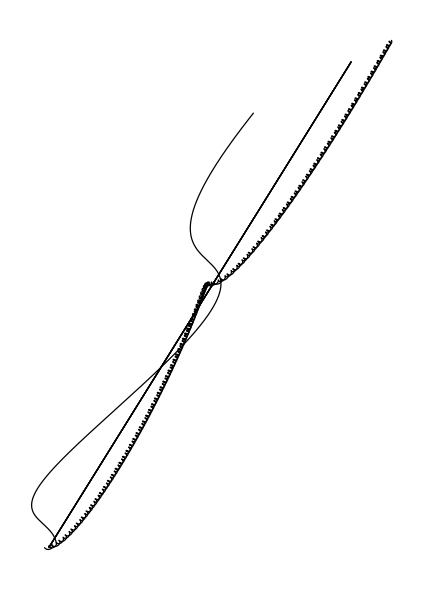

In [10]:
# Triple system that is designed to disrupt
# One cell, ready to run

import numpy as np
import matplotlib.pyplot as plt

# =========================
# Controls
# =========================
SEED = 7
np.random.seed(SEED)

# Physics
G = 1.0

# Visuals
figsize = (12, 6)
bg = "white"
linewidth = 0.9
fade_tail = False
drift_speed = 0.35
save_svg = True
svg_name = "triple_forced_disruption.svg"

# Force regularization and clamps
soft_eps = 3e-3           # smaller softening makes close passes stronger
R_MIN = 0.0
A_PAIR_MAX = None
A_MAX = None

# Integrator
STEPS = 90000             # enough to cover several outer periods
DT_PER_INNER = 1000       # dt = inner_period / DT_PER_INNER (1000 is safe)
                         # increase to 1400 for more accuracy if needed

# Plot COM as thick line by overdrawing
com_passes = 5
com_jitter = 0.0

# Preset switch
# "FORCE_EXPLODE" is tuned to disrupt quickly and reliably
PRESET = "FORCE_EXPLODE"  # alternatives: "NEAR_LIMIT_SLOW"

# Tiny random velocity noise to break symmetry
VEL_NOISE_FRAC = 0.003

# =========================
# Utilities
# =========================
def clamp_vecs(v, max_norm):
    if max_norm is None:
        return v
    n = np.linalg.norm(v, axis=1) + 1e-12
    s = np.minimum(1.0, max_norm / n)
    return v * s[:, None]

def pairwise_acc(p, m, G=1.0, eps=1e-3, r_min=0.0, a_pair_max=None, a_total_max=None):
    N = p.shape[0]
    A = np.zeros_like(p)
    rmin2 = r_min*r_min
    eps2 = eps*eps
    for i in range(N):
        d = p - p[i]
        dist2 = np.sum(d*d, axis=1)
        dist2 = np.maximum(dist2, rmin2) + eps2
        mask = np.ones(N, bool); mask[i] = False
        d_ij = d[mask]
        m_ij = m[mask]
        invr3 = dist2[mask] ** (-1.5)
        contrib = (G * m_ij)[:, None] * d_ij * invr3[:, None]
        contrib = clamp_vecs(contrib, a_pair_max)
        A[i] = contrib.sum(axis=0)
    if a_total_max is not None:
        A = clamp_vecs(A, a_total_max)
    return A

def vis_viva_speed(GM, r, a):
    return np.sqrt(GM * (2.0 / r - 1.0 / a))

def mardling_aout_over_ain(m1, m2, m3, e_out, e_in=0.0):
    # Mardling and Aarseth 2001, coplanar approximation
    q_out = m3 / (m1 + m2)
    return 2.8 * (1.0 + q_out)**(2.0/5.0) * (1.0 + e_out) / (1.0 - e_out)**(3.0/5.0)

def build_triple_for_disruption(
    G=1.0,
    m1=1.0, m2=0.85, m3=0.75,
    a_in=1.0, e_in=0.18, f_in_deg=170.0,
    # outer chosen just below stability limit with high eccentricity and near pericenter
    e_out=0.68, f_out_deg=10.0,
    k_margin=0.85,                  # fraction of the stability threshold
    rotation_deg=15.0,
    vel_boost_outer=1.03,           # small super-Kepler boost, helps disruption
    vel_scale_inner=1.00,           # 0.95 inward spiral, 1.00 nominal
    add_noise_frac=0.0,
    rng=np.random.default_rng(SEED+101),
):
    M12 = m1 + m2
    Mtot = M12 + m3

    f_in = np.deg2rad(f_in_deg)
    f_out = np.deg2rad(f_out_deg)

    # a_out from threshold
    a_out_crit = mardling_aout_over_ain(m1, m2, m3, e_out, e_in) * a_in
    a_out = k_margin * a_out_crit

    # inner true radius and velocity
    r_in = a_in * (1.0 - e_in**2) / (1.0 + e_in * np.cos(f_in))
    vrel_in = vis_viva_speed(G*M12, r_in, a_in)
    rhat_in = np.array([np.cos(f_in), np.sin(f_in)])
    that_in = np.array([-np.sin(f_in), np.cos(f_in)])
    r_vec = r_in * rhat_in
    v_vec = vrel_in * that_in

    # split around inner barycenter
    p1 = -(m2 / M12) * r_vec
    p2 = +(m1 / M12) * r_vec
    v1 = -(m2 / M12) * v_vec
    v2 = +(m1 / M12) * v_vec

    # outer body at f_out
    r_out = a_out * (1.0 - e_out**2) / (1.0 + e_out * np.cos(f_out))
    v_out_mag = vis_viva_speed(G*Mtot, r_out, a_out)
    rhat_out = np.array([np.cos(f_out), np.sin(f_out)])
    that_out = np.array([-np.sin(f_out), np.cos(f_out)])
    p3 = r_out * rhat_out
    v3 = v_out_mag * that_out

    # rotate the whole system for aesthetics
    rot = np.deg2rad(rotation_deg)
    c, s = np.cos(rot), np.sin(rot)
    R2 = np.array([[c, -s], [s, c]])
    pos = np.vstack([p1, p2, p3]) @ R2.T
    vel = np.vstack([v1, v2, v3]) @ R2.T

    # scale inner pair and boost outer a bit
    vel[:2] *= vel_scale_inner
    vel[2] *= vel_boost_outer

    # tiny random velocity noise relative to inner circular speed
    speed_circ_inner = np.sqrt(G*M12 / a_in)
    vel += add_noise_frac * speed_circ_inner * rng.normal(size=vel.shape)

    masses = np.array([m1, m2, m3], float)

    # inner orbital period for dt
    T_in = 2.0 * np.pi * np.sqrt(a_in**3 / (G * M12))

    info = dict(
        a_out=a_out, a_in=a_in, e_in=e_in, e_out=e_out,
        aout_over_ain=a_out / a_in, stability_limit=a_out_crit / a_in,
        q_out_pericenter = a_out * (1.0 - e_out)
    )
    return pos, vel, masses, T_in, info

def build_triple_near_limit(
    G=1.0,
    m1=1.0, m2=0.85, m3=0.55,
    a_in=1.0, e_in=0.10, f_in_deg=20.0,
    e_out=0.45, f_out_deg=180.0,
    k_margin=0.96,
    rotation_deg=10.0,
    vel_boost_outer=1.00,
    vel_scale_inner=1.00,
    add_noise_frac=0.0,
):
    return build_triple_for_disruption(
        G=G, m1=m1, m2=m2, m3=m3,
        a_in=a_in, e_in=e_in, f_in_deg=f_in_deg,
        e_out=e_out, f_out_deg=f_out_deg,
        k_margin=k_margin, rotation_deg=rotation_deg,
        vel_boost_outer=vel_boost_outer,
        vel_scale_inner=vel_scale_inner,
        add_noise_frac=add_noise_frac,
    )

# =========================
# Pick preset
# =========================
if PRESET == "FORCE_EXPLODE":
    pos0, vel0, masses, T_in, info = build_triple_for_disruption(
        G=G,
        m1=1.0, m2=0.85, m3=0.75,
        a_in=1.0, e_in=0.18, f_in_deg=170.0,     # inner near apocenter
        e_out=0.68, f_out_deg=10.0,              # outer near pericenter
        k_margin=0.85,                           # below stability threshold
        rotation_deg=15.0,
        vel_boost_outer=1.03,                    # small extra energy
        vel_scale_inner=1.00,
        add_noise_frac=VEL_NOISE_FRAC,
    )
else:
    pos0, vel0, masses, T_in, info = build_triple_near_limit(
        G=G,
        m1=1.0, m2=0.85, m3=0.60,
        a_in=1.0, e_in=0.12, f_in_deg=0.0,
        e_out=0.50, f_out_deg=180.0,
        k_margin=0.95,
        rotation_deg=10.0,
        vel_boost_outer=1.00,
        vel_scale_inner=1.00,
        add_noise_frac=VEL_NOISE_FRAC,
    )

dt = T_in / DT_PER_INNER

print(f"Inner period ~ {T_in:.4f}, dt = {dt:.6f}, steps = {STEPS}")
print(f"a_out/a_in = {info['aout_over_ain']:.3f}, stability limit ~ {info['stability_limit']:.3f}, "
      f"outer pericenter q_out ~ {info['q_out_pericenter']:.3f} a_in")

# =========================
# Integrate
# =========================
p = pos0.copy()
v = vel0.copy()

traj = np.zeros((STEPS, 3, 2), float)
com_traj = np.zeros((STEPS, 2), float)

for t in range(STEPS):
    drift = np.array([drift_speed * t * dt, 0.0])

    a0 = pairwise_acc(p, masses, G=G, eps=soft_eps, r_min=R_MIN,
                      a_pair_max=A_PAIR_MAX, a_total_max=A_MAX)
    p_half = p + v*dt + 0.5*a0*(dt*dt)
    a1 = pairwise_acc(p_half, masses, G=G, eps=soft_eps, r_min=R_MIN,
                      a_pair_max=A_PAIR_MAX, a_total_max=A_MAX)
    v = v + 0.5*(a0 + a1)*dt
    p = p_half

    traj[t] = p + drift
    com = (masses[:, None] * p).sum(axis=0) / masses.sum()
    com_traj[t] = com + drift

# =========================
# Plot
# =========================
plt.figure(figsize=figsize, facecolor=bg)
ax = plt.gca(); ax.set_facecolor(bg)

T = traj
COM = com_traj

# all black for pen-plot look
for k in range(3):
    if fade_tail:
        alphas = np.linspace(0.05, 0.95, T.shape[0])
        for i in range(T.shape[0] - 1):
            ax.plot(T[i:i+2, k, 0], T[i:i+2, k, 1], color="k", lw=linewidth, alpha=alphas[i])
    else:
        ax.plot(T[:, k, 0], T[:, k, 1], color="k", lw=linewidth)

rng = np.random.default_rng(SEED + 12345)
for _ in range(com_passes):
    jitter = rng.normal(scale=com_jitter, size=COM.shape)
    ax.plot(COM[:, 0] + jitter[:, 0], COM[:, 1] + jitter[:, 1], color="k", lw=linewidth)

ax.set_aspect("equal", adjustable="box")
ax.axis("off")

xmin = np.min(T[:, :, 0]); xmax = np.max(T[:, :, 0])
ymin = np.min(T[:, :, 1]); ymax = np.max(T[:, :, 1])
xspan = (xmax - xmin) + 1e-9; yspan = (ymax - ymin) + 1e-9
xpad = 0.06 * xspan; ypad = 0.06 * yspan
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

plt.tight_layout()
if save_svg:
    plt.savefig(svg_name, bbox_inches="tight")
plt.show()
